In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Ideas for future model improvement
Thoughts regarding each of the improvements below:
- Integrating domain knowledge: polyps do not go back to planulas.
- Integrating video knowledge: there are always the same number of things, AND they don't suddenly disappear: if a prediction is not within a certain distance from predictions in the previous image, it's not right and we can remove it
- Similarly, if there is no prediction within a certain distance of predictions in the previous image, it's not right and we can add from the previous image
- Overlap: think about this further

Essentially, for each new prediction $p_i$ in image $k$, we check image $k-1$ to determine if $p_i$ has a corresponding prediction that is close enough. What is "close enough"? That's up to the user, but I think w/in 20 pixels is a good starting point.
- If a prediction is NOT w/in a certain distance from a prediction in the previous image, we can remove it
- If a prediction from the previous image does NOT have a corresponding prediction w/in a certain distance in the current image, we can copy one over (introduces some small error which gets magnified over frames)

In [3]:
df = pd.read_csv("annotations_test.csv")
df.head()

,Unnamed: 0,image_filename,x1,y1,x2,y2,conf,class
0,0,glw_ac_16c_4_dpf_fert_04_10_20261314.png,643.28790,489.06598,652.81506,499.62698,0.930002,0.0
1,1,glw_ac_16c_4_dpf_fert_04_10_20261314.png,592.38367,389.81903,602.39280,400.38950,0.920628,0.0
2,2,glw_ac_16c_4_dpf_fert_04_10_20261314.png,699.93240,222.09018,711.63120,234.96510,0.911168,0.0
3,3,glw_ac_16c_4_dpf_fert_04_10_20261314.png,156.43477,634.05590,166.51900,644.86224,0.911006,0.0
4,4,glw_ac_16c_4_dpf_fert_04_10_20261314.png,543.77380,310.59440,554.41130,321.52216,0.906934,0.0


In [4]:
filenames = df["image_filename"].unique()
filenames = np.sort(filenames) #sorting only the filenames makes this a lot quicker later
df_individuals = []

for f in filenames:
    df_individuals.append(df[df.image_filename == f])

df_lens = [len(d) for d in df_individuals]

(array([457.,   0.,   0., 870.,   0.,   0., 459.,   0.,   0.,  13.]),
 array([18. , 18.3, 18.6, 18.9, 19.2, 19.5, 19.8, 20.1, 20.4, 20.7, 21. ]),
 <BarContainer object of 10 artists>)

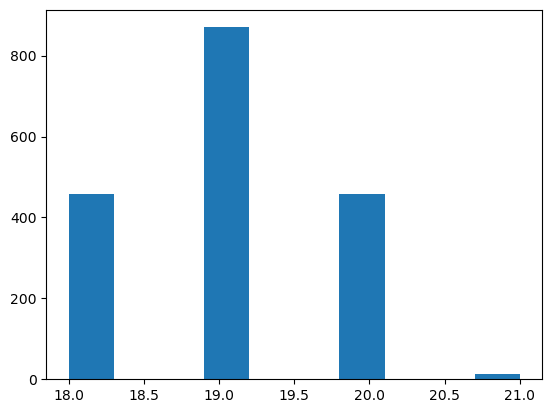

In [5]:
plt.hist(df_lens)

In [6]:
df_individuals[0]

,Unnamed: 0,image_filename,x1,y1,x2,y2,conf,class
29699,29699,glw_ac_16c_4_dpf_fert_04_10_20260001.png,814.16920,579.13870,823.80150,588.85364,0.926776,0.0
29700,29700,glw_ac_16c_4_dpf_fert_04_10_20260001.png,591.10223,390.81110,601.18976,401.72080,0.923731,0.0
29701,29701,glw_ac_16c_4_dpf_fert_04_10_20260001.png,156.53076,633.68540,166.75790,644.61584,0.913662,0.0
29702,29702,glw_ac_16c_4_dpf_fert_04_10_20260001.png,542.23250,308.48367,553.26105,319.19257,0.911262,0.0
29703,29703,glw_ac_16c_4_dpf_fert_04_10_20260001.png,276.39285,341.55508,287.12125,353.40200,0.909188,0.0
29704,29704,glw_ac_16c_4_dpf_fert_04_10_20260001.png,649.90326,832.62915,660.52140,843.74960,0.903688,0.0
29705,29705,glw_ac_16c_4_dpf_fert_04_10_20260001.png,559.04443,486.16632,569.70610,497.19305,0.901891,0.0
29706,29706,glw_ac_16c_4_dpf_fert_04_10_20260001.png,701.30650,221.41888,713.87990,233.82092,0.899892,0.0
29707,29707,glw_ac_16c_4_dpf_fert_04_10_20260001.png,643.41614,489.19485,653.04170,500.12863,0.893710,0.0
29708,29708,glw_ac_16c_4_dpf_fert_04_10_20260001.png,656.19055,453.44492,668.14760,464.95825,0.893004,0.0


## Overlap Removal
For every pair $j, k$ in every `df_individuals[i]`, we check the intersection over union (IoU) of $j, k$. If that IoU is above a certain tolerance level, we remove $j$ or $k$ arbitrarily (in this implementation, we only remove $j$). 

In [ ]:
"""Intersection over Union for two boxes given in the form of arrays [x1, y1, x2, y2]."""
def iou(a, b):
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])

    inter = max(0, x2 - x1) * max(0, y2 - y1)
    if inter == 0:
        return 0.0
    
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (area_a + area_b - inter)

def remove_overlap(df, tolerance = 0.8):
    boxes_to_remove = []

    for j in range(len(df)):
        for k in range(len(df)):
            if j == k:
                continue
            
            box_a = [df.iloc[j]["x1"], df.iloc[j]["y1"], df.iloc[j]["x2"], df.iloc[j]["y2"]]
            box_b = [df.iloc[k]["x1"], df.iloc[k]["y1"], df.iloc[k]["x2"], df.iloc[k]["y2"]]

            overlap = iou(box_a, box_b)
            if overlap > tolerance:
                boxes_to_remove.append(j)
                break
    
    return boxes_to_remove



## Forward Imputation
Here, we take from `df_individuals[i]` (assuming it is correct) and add to `df_individuals[i+1]`. For every item $k$ in `df_individuals[i]`, we look and see if there is a corresponding prediction in `df_individuals[i+1]` within some distance of tolerance. If there is not, we add $k$ to `df_individuals[i+1]`.

## Backward Validation
Here, we take from `df_individuals[i+1]` and modify ITSELF by looking at `df_individuals[i]` (assuming it is correct). For every item $k$ in `df_individuals[i+1]`, we look and see if there is a corresponding prediction in `df_individuals[i]` within some distance of tolerance. If there is not, we remove $k$ from `df_individuals[i+1]`. 